# Natural Language Processing



This project will give you practical experience using Natural Language Processing techniques. This project is in three parts:
- in part 1) you will use a dataset in a CSV file
- in part 2) you will use the Wikipedia API to directly access content
on Wikipedia.
- in part 3) you will make your notebook interactive


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



### Part 2)



- For the same reference person that you chose in Part 1), use the Wikipedia API to access the whole content of the reference person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the reference person
  1. Determine the sentiment of the text of the Wikipedia page for the reference person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [78]:
!curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv | wc -l

42786


In [79]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -1 |
tr , '\n' |
cat -n


     1	URI
     2	name
     3	text


In [80]:
%%bash
curl -s https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv |
head -2 |
tail -1 |
tr , '\n' |
cat -n


     1	<http://dbpedia.org/resource/Digby_Morrell>
     2	Digby Morrell
     3	digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play v

In [81]:
# Install wikipedia and textblob if not already present

!pip install wikipedia textblob -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wikipedia
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import ipywidgets as widgets
from IPython.display import display, clear_output

In [82]:
# Load dataset directly from S3 bucket

url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"
df = pd.read_csv(url)

In [83]:
# Data Cleaning

# Deduplicate records based on URI/name while keeping the first occurrence

df.drop_duplicates(subset=['URI'], keep='first', inplace=True)
df.drop_duplicates(subset=['name'], keep='first', inplace=True)

In [84]:
# Clean the 'name' column: strip excess spaces and normalize whitespace/special characters

df['name'] = df['name'].str.replace(r'[^\w\s\(\)\.-]', '', regex=True).str.strip()
df['name'] = df['name'].str.replace(r'\s+', ' ', regex=True)

In [85]:
# Clean the 'text' column: strip leading/trailing spaces and ensure clean single spaces

df['text'] = df['text'].astype(str).str.replace(r'[^\w\s]', '', regex=True)
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [86]:
# Handle any missing values if present

df.dropna(subset=['name', 'text'], inplace=True)

In [87]:
# Reset DataFrame index so position-based indexing aligns perfectly with matrix rows

df.reset_index(drop=True, inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")

Cleaned Dataset Shape: (42785, 3)


In [88]:
# Output dataset dimension and preview

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (42785, 3)


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


### Part 1)



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the reference person



In [89]:
# Initialize TF-IDF Vectorizer ignoring standard English stop words

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['text'])

In [90]:
tfidf

TfidfVectorizer(stop_words='english')

In [91]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5847140 stored elements and shape (42785, 437241)>

In [92]:
# Initialize Nearest Neighbors with Cosine Distance

knn_csv = NearestNeighbors(n_neighbors=11, metric='cosine')
knn_csv.fit(tfidf_matrix)

NearestNeighbors(metric='cosine', n_neighbors=11)

In [93]:
from IPython.display import display

def analyze_part1(reference_name):
    # Locate index of chosen individual
    ref_idx = df[df['name'].str.lower() == reference_name.lower()].index
    if len(ref_idx) == 0:
        print(f"Error: '{reference_name}' not found in dataset.")
        return None, None

    idx = ref_idx[0]
    ref_text = df.loc[idx, 'text']

    # Query KNN for nearest TF-IDF vectors

    distances, indices = knn_csv.kneighbors(tfidf_matrix[idx])

    # Exclude self-match (index 0)

    neighbor_indices = indices[0][1:]
    neighbor_distances = distances[0][1:]

    # Form dataframe for top 10 matches

    top_10_csv = df.iloc[neighbor_indices].copy()
    top_10_csv['csv_distance'] = neighbor_distances
    top_10_csv['csv_rank'] = range(1, 11)

    # Analyze Sentiment

    blob = TextBlob(ref_text)
    print(f"== OVERVIEW ANALYSIS FOR '{df.loc[idx, 'name']}'==\n")
    print(f"Polarity: {blob.sentiment.polarity:.4f} (-1.0 = Negative, 1.0 = Positive)")
    print(f"Subjectivity: {blob.sentiment.subjectivity:.4f} (0.0 = Objective, 1.0 = Subjective)\n")

    print("== Top 10 Nearest Neighbors (CSV Overview) ==")

    # Display results as a cleanly formatted DataFrame

    results_df = top_10_csv[['csv_rank', 'name', 'csv_distance']].rename(columns={
        'csv_rank': 'Rank',
        'name': 'Name',
        'csv_distance': 'Cosine Distance'
    }).reset_index(drop=True)

    display(results_df)

    return idx, top_10_csv

# Run Part 1 for reference individual

ref_person = "Barack Obama"
ref_idx, top_10_csv = analyze_part1(ref_person)

== OVERVIEW ANALYSIS FOR 'Barack Obama'==

Polarity: 0.0787 (-1.0 = Negative, 1.0 = Positive)
Subjectivity: 0.2787 (0.0 = Objective, 1.0 = Subjective)

== Top 10 Nearest Neighbors (CSV Overview) ==


,Rank,Name,Cosine Distance
0,1,Joe Biden,0.674969
1,2,Samantha Power,0.725510
2,3,Eric Stern (politician),0.745290
3,4,Henry Waxman,0.772334
4,5,Eric Holder,0.776298
5,6,Joe the Plumber,0.779372
6,7,Phil Schiliro,0.784489
7,8,Kenneth D. Thompson,0.798260
8,9,John McCain,0.799132
9,10,George W. Bush,0.800006


In [94]:
wikipedia.set_lang("en")
ref_name_str = df.loc[ref_idx, 'name']

try:
    # Query Wikipedia API
    ref_wiki_page = wikipedia.page(ref_name_str, auto_suggest=False)
    ref_wiki_text = ref_wiki_page.content
except Exception as e:
    print(f"Wikipedia fetch error for {ref_name_str}: {e}")
    ref_wiki_text = df.loc[ref_idx, 'text'] # Fallback to CSV text

# Print snippet and compute sentiment
print(f"=== PART 2: WIKIPEDIA PAGE ANALYSIS FOR '{ref_name_str}' ===\n")
print(f"Wiki Text Preview (First 400 chars):\n{ref_wiki_text[:400]}...\n")

wiki_blob = TextBlob(ref_wiki_text)
print(f"Full Wikipedia Polarity: {wiki_blob.sentiment.polarity:.4f}")
print(f"Full Wikipedia Subjectivity: {wiki_blob.sentiment.subjectivity:.4f}\n")

=== PART 2: WIKIPEDIA PAGE ANALYSIS FOR 'Barack Obama' ===

Wiki Text Preview (First 400 chars):
Barack Hussein Obama II (born August 4, 1961) is an American former politician who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African American to serve as president. Obama represented Illinois in the United States Senate from 2005 to 2008 and served as an Illinois state senator from 1997 to 2004.
Born in Honolulu, Obama g...

Full Wikipedia Polarity: 0.1082
Full Wikipedia Subjectivity: 0.3312



In [95]:
from sklearn.metrics.pairwise import cosine_distances
from IPython.display import display

# List of individuals: Reference person + 10 CSV neighbors
people_list = [ref_name_str] + list(top_10_csv['name'])
wiki_texts = []

# Fetch Wikipedia articles for all 11 individuals
for person in people_list:
    try:
        page = wikipedia.page(person, auto_suggest=False)
        wiki_texts.append(page.content)
    except Exception:
        # Fallback if API fails or page title differs
        csv_fallback = df[df['name'] == person]['text'].values[0]
        wiki_texts.append(csv_fallback)

# Re-vectorize full Wikipedia texts
tfidf_wiki = TfidfVectorizer(stop_words='english')
wiki_matrix = tfidf_wiki.fit_transform(wiki_texts)

# Compute Cosine Distance from Reference Person (index 0) to Neighbors (indices 1 to 10)
distances_wiki = cosine_distances(wiki_matrix[0], wiki_matrix[1:])[0]

# Build Comparison DataFrame
comparison_df = top_10_csv[['name', 'csv_rank']].copy()
comparison_df['wiki_distance'] = distances_wiki
comparison_df['wiki_rank'] = comparison_df['wiki_distance'].rank(method='min').astype(int)
comparison_df['rank_difference'] = comparison_df['wiki_rank'] - comparison_df['csv_rank']

# Clean up column names for display
display_df = comparison_df[['name', 'csv_rank', 'wiki_rank', 'rank_difference']].rename(columns={
    'name': 'Name',
    'csv_rank': 'Overview Rank',
    'wiki_rank': 'Wiki Page Rank',
    'rank_difference': 'Rank Difference'
}).reset_index(drop=True)

print("--- Rank Comparison Table (CSV Overview Rank vs. Full Wikipedia Rank) ---")
display(display_df)

--- Rank Comparison Table (CSV Overview Rank vs. Full Wikipedia Rank) ---


,Name,Overview Rank,Wiki Page Rank,Rank Difference
0,Joe Biden,1,3,2
1,Samantha Power,2,1,-1
2,Eric Stern (politician),3,8,5
3,Henry Waxman,4,10,6
4,Eric Holder,5,9,4
5,Joe the Plumber,6,6,0
6,Phil Schiliro,7,7,0
7,Kenneth D. Thompson,8,5,-3
8,John McCain,9,4,-5
9,George W. Bush,10,2,-8


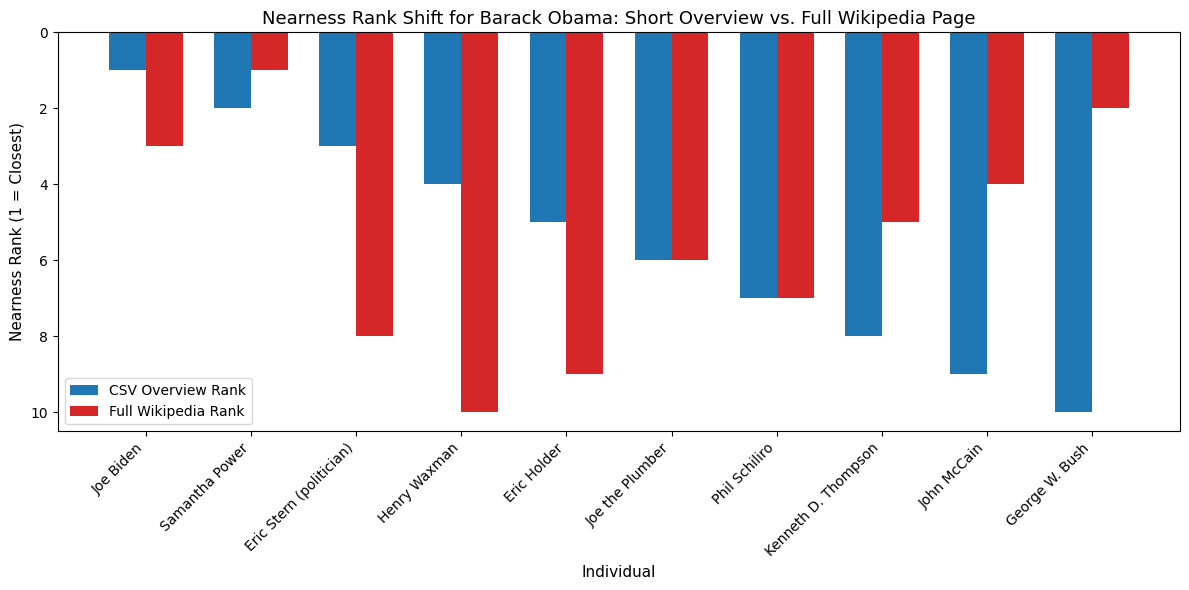

In [96]:
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

# Plot side-by-side bars

plt.bar(x - width/2, comparison_df['csv_rank'], width, label='CSV Overview Rank', color='#1f77b4')
plt.bar(x + width/2, comparison_df['wiki_rank'], width, label='Full Wikipedia Rank', color='#d62728')

# Format plot

plt.xlabel('Individual', fontsize=11)
plt.ylabel('Nearness Rank (1 = Closest)', fontsize=11)
plt.title(f'Nearness Rank Shift for {ref_name_str}: Short Overview vs. Full Wikipedia Page', fontsize=13)
plt.xticks(x, comparison_df['name'], rotation=45, ha='right')
plt.gca().invert_yaxis() # Invert Y-axis so Rank 1 appears at top
plt.legend()
plt.tight_layout()
plt.show()

### Part 3)


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [97]:
# Create Interactive Widgets

name_input = widgets.Text(
    value='Barack Obama',
    description='Person Name:',
    placeholder='Type a name from DBpedia dataset...',
    disabled=False
)

search_button = widgets.Button(description="Find 10 Closest", button_style='primary')
output_display = widgets.Output()

def run_interactive_search(b):
    with output_display:
        clear_output()
        query_name = name_input.value.strip()

        # Look up match in dataset
        match = df[df['name'].str.lower() == query_name.lower()]

        # Case-insensitive substring fallback
        if len(match) == 0:
            match = df[df['name'].str.lower().str.contains(query_name.lower())]

        if len(match) == 0:
            print(f"No entry found for '{query_name}'. Please try another name in the DBpedia set.")
            return

        found_name = match.iloc[0]['name']
        found_idx = match.index[0]

        print(f"Selected: {found_name}\n")

        # 1. Compute Overview Sentiment & Display as DataFrame
        blob = TextBlob(df.loc[found_idx, 'text'])
        sentiment_df = pd.DataFrame([{
            'Entity': found_name,
            'Polarity': f"{blob.sentiment.polarity:.4f}",
            'Subjectivity': f"{blob.sentiment.subjectivity:.4f}"
        }])

        print("--- Sentiment Metrics ---")
        display(sentiment_df)
        print("\n")

        # 2. Query Nearest Neighbors
        distances, indices = knn_csv.kneighbors(tfidf_matrix[found_idx])

        # Format Top 10 Output DataFrame
        top_10 = df.iloc[indices[0][1:]].copy()
        top_10['cosine_distance'] = distances[0][1:]
        top_10['rank'] = range(1, 11)

        display_results = top_10[['rank', 'name', 'cosine_distance']].rename(columns={
            'rank': 'Rank',
            'name': 'Name',
            'cosine_distance': 'Cosine Distance'
        }).reset_index(drop=True)

        print("--- Top 10 Closest Individuals ---")
        display(display_results)

# Bind event handler to button

search_button.on_click(run_interactive_search)

# Render Widget UI

print("=== INTERACTIVE NLP NEAREST NEIGHBOR EXPLORER ===\n")
display(widgets.HBox([name_input, search_button]), output_display)

=== INTERACTIVE NLP NEAREST NEIGHBOR EXPLORER ===



Output()